# 01 — Data Preprocessing
**Project:** Lightweight IDS for Raspberry Pi (Edge IDS Internship)  
**Reference:** Musthafa et al., IEEE Access 2025  
**Dataset:** UNSW-NB15  

**What this notebook does:**
1. Loads UNSW-NB15 train/test CSVs
2. Cleans and encodes categorical features
3. Applies StandardScaler
4. Runs ANOVA F-test → selects top 36 features (paper-aligned)
5. Saves all artifacts to `artifacts/` folder for downstream notebooks

**Outputs saved:**
```
artifacts/
  X_train.npy          # (82332, 36) float32
  X_test.npy           # (175341, 36) float32
  y_train.npy          # (82332,)  int
  y_test.npy           # (175341,) int
  scaler.pkl           # fitted StandardScaler
  label_encoders.pkl   # fitted LabelEncoders for proto/service/state
  selected_features.json  # list of 36 ANOVA-selected feature names
```

## 1. Imports

In [1]:
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import f_classif
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 300, 'axes.titlesize': 13})

SEED = 42
np.random.seed(SEED)

print('All imports successful ✓')

All imports successful ✓


## 2. Config — set your paths here

In [2]:
# ── CHANGE THESE to match your folder structure ───────────────────────────────
BASE_DIR   = "../"  # root of your project
TRAIN_PATH = os.path.join(BASE_DIR, 'data', 'UNSW_NB15', 'UNSW_NB15_training-set.csv')
TEST_PATH  = os.path.join(BASE_DIR, 'data', 'UNSW_NB15', 'UNSW_NB15_testing-set.csv')
# ─────────────────────────────────────────────────────────────────────────────

ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

N_FEATURES = 36   # paper uses top-36 ANOVA features
TARGET     = 'label'
CAT_COLS   = ['proto', 'service', 'state']
DROP_COLS  = ['id', 'attack_cat']

print('Config set ✓')
print(f'Artifacts will be saved to: {ARTIFACTS_DIR}')

# Sanity check — files exist?
for name, path in [('Train', TRAIN_PATH), ('Test', TEST_PATH)]:
    status = '✓ found' if os.path.exists(path) else '✗ NOT FOUND — update path above'
    print(f'  {name}: {status}')

Config set ✓
Artifacts will be saved to: ../artifacts
  Train: ✓ found
  Test: ✓ found


## 3. Load Data

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f'Train shape : {train_df.shape}')   # expected (82332, 49)
print(f'Test  shape : {test_df.shape}')    # expected (175341, 49)
print()
print('Train label distribution:')
print(train_df[TARGET].value_counts().rename({0: 'Normal', 1: 'Attack'}))
print()
print('Test label distribution:')
print(test_df[TARGET].value_counts().rename({0: 'Normal', 1: 'Attack'}))

Train shape : (82332, 45)
Test  shape : (175341, 45)

Train label distribution:
label
Attack    45332
Normal    37000
Name: count, dtype: int64

Test label distribution:
label
Attack    119341
Normal     56000
Name: count, dtype: int64


In [4]:
# Quick look at the data
train_df.head(5)

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [5]:
# Check for missing values
miss_train = train_df.isnull().sum()
miss_test  = test_df.isnull().sum()

if miss_train.any():
    print('Missing in train:', miss_train[miss_train > 0].to_dict())
else:
    print('No missing values in train ✓')

if miss_test.any():
    print('Missing in test:', miss_test[miss_test > 0].to_dict())
else:
    print('No missing values in test ✓')

No missing values in train ✓
No missing values in test ✓


## 4. Class Distribution Plot

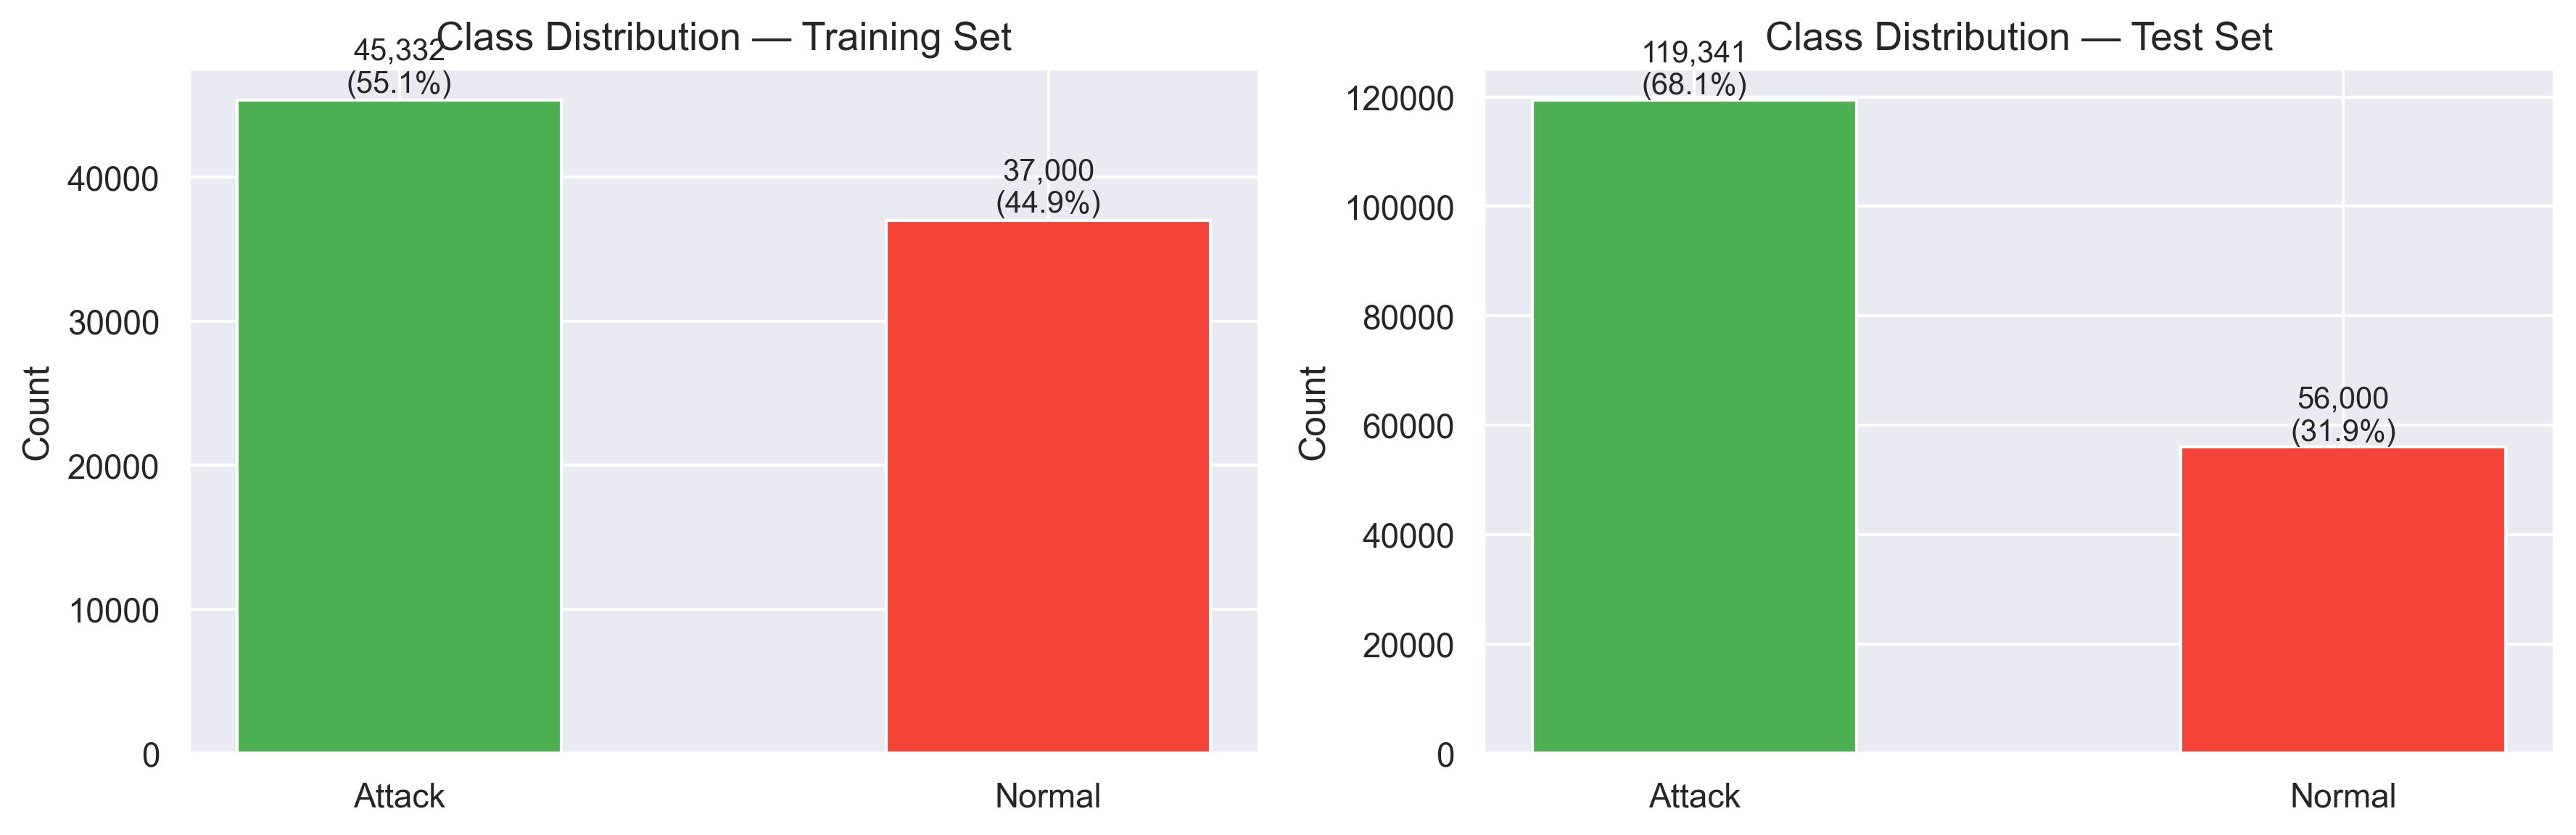

Plot saved ✓


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes, [train_df, test_df], ['Training Set', 'Test Set']):
    counts = df[TARGET].map({0: 'Normal', 1: 'Attack'}).value_counts()
    colors = ['#4CAF50', '#F44336']
    bars   = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
    ax.set_title(f'Class Distribution — {title}')
    ax.set_ylabel('Count')
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 200,
            f'{h:,}\n({h / len(df) * 100:.1f}%)',
            ha='center', va='bottom', fontsize=10
        )

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'class_distribution.png'), bbox_inches='tight')
plt.show()
print('Plot saved ✓')

## 5. Preprocessing

Steps:
- Drop `id` (row identifier) and `attack_cat` (not needed for binary task)
- Strip whitespace from categorical columns
- Label-encode `proto`, `service`, `state`
- StandardScale all numeric features (fit on train, transform both)

In [7]:
def preprocess(df, encoders=None, fit=True):
    """
    Clean and encode the UNSW-NB15 dataframe.

    Parameters
    ----------
    df       : raw DataFrame
    encoders : dict of fitted LabelEncoders (None when fit=True)
    fit      : if True, fit new encoders on this data

    Returns
    -------
    df       : processed DataFrame (label column intact)
    encoders : dict of LabelEncoders
    """
    df = df.drop(columns=DROP_COLS, errors='ignore').copy()

    # Strip whitespace
    df[CAT_COLS] = df[CAT_COLS].apply(lambda c: c.str.strip())

    if fit:
        encoders = {col: LabelEncoder() for col in CAT_COLS}
        for col in CAT_COLS:
            df[col] = encoders[col].fit_transform(df[col].astype(str))
    else:
        # Handle unseen categories gracefully → map to -1
        for col in CAT_COLS:
            le = encoders[col]
            df[col] = df[col].astype(str).map(
                lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
            )

    return df, encoders


train_proc, encoders = preprocess(train_df, fit=True)
test_proc,  _        = preprocess(test_df,  encoders=encoders, fit=False)

X_train_raw = train_proc.drop(columns=[TARGET])
y_train     = train_proc[TARGET].values.astype(int)
X_test_raw  = test_proc.drop(columns=[TARGET])
y_test      = test_proc[TARGET].values.astype(int)

print(f'X_train_raw : {X_train_raw.shape}')  # (82332, 45)
print(f'X_test_raw  : {X_test_raw.shape}')   # (175341, 45)
print('Encoding done ✓')

X_train_raw : (82332, 42)
X_test_raw  : (175341, 42)
Encoding done ✓


In [8]:
# StandardScaler — fit on train only
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train_raw)
X_test_scaled   = scaler.transform(X_test_raw)

print('StandardScaler fitted and applied ✓')
print(f'Train mean (first feature): {X_train_scaled[:, 0].mean():.6f}  (should be ~0)')  
print(f'Train std  (first feature): {X_train_scaled[:, 0].std():.6f}   (should be ~1)')

StandardScaler fitted and applied ✓
Train mean (first feature): -0.000000  (should be ~0)
Train std  (first feature): 1.000000   (should be ~1)


## 6. ANOVA Feature Selection

Paper (Musthafa et al., 2025) selects **top 36 features** using ANOVA F-test.  
F-test measures how much each feature's variance differs across classes (Normal vs Attack).  
Higher F-score → more discriminative → keep it.

In [9]:
f_scores, p_values = f_classif(X_train_scaled, y_train)

anova_df = pd.DataFrame({
    'feature' : X_train_raw.columns.tolist(),
    'f_score' : f_scores,
    'p_value' : p_values
}).sort_values('f_score', ascending=False).reset_index(drop=True)

selected_features = anova_df.head(N_FEATURES)['feature'].tolist()
eliminated        = anova_df.tail(len(anova_df) - N_FEATURES)['feature'].tolist()

print(f'Total features      : {len(anova_df)}')
print(f'Selected (top {N_FEATURES}) : {selected_features}')
print(f'Eliminated          : {eliminated}')

Total features      : 42
Selected (top 36) : ['sttl', 'state', 'swin', 'ct_dst_sport_ltm', 'dwin', 'ct_src_dport_ltm', 'rate', 'ct_state_ttl', 'ct_srv_dst', 'ct_srv_src', 'dtcpb', 'stcpb', 'dload', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_dst_ltm', 'dmean', 'synack', 'tcprtt', 'service', 'sload', 'sinpkt', 'ackdat', 'is_sm_ips_ports', 'dttl', 'ct_flw_http_mthd', 'dpkts', 'smean', 'dloss', 'dinpkt', 'dbytes', 'spkts', 'sjit', 'djit', 'trans_depth', 'sbytes']
Eliminated          : ['ct_ftp_cmd', 'response_body_len', 'is_ftp_login', 'sloss', 'proto', 'dur']


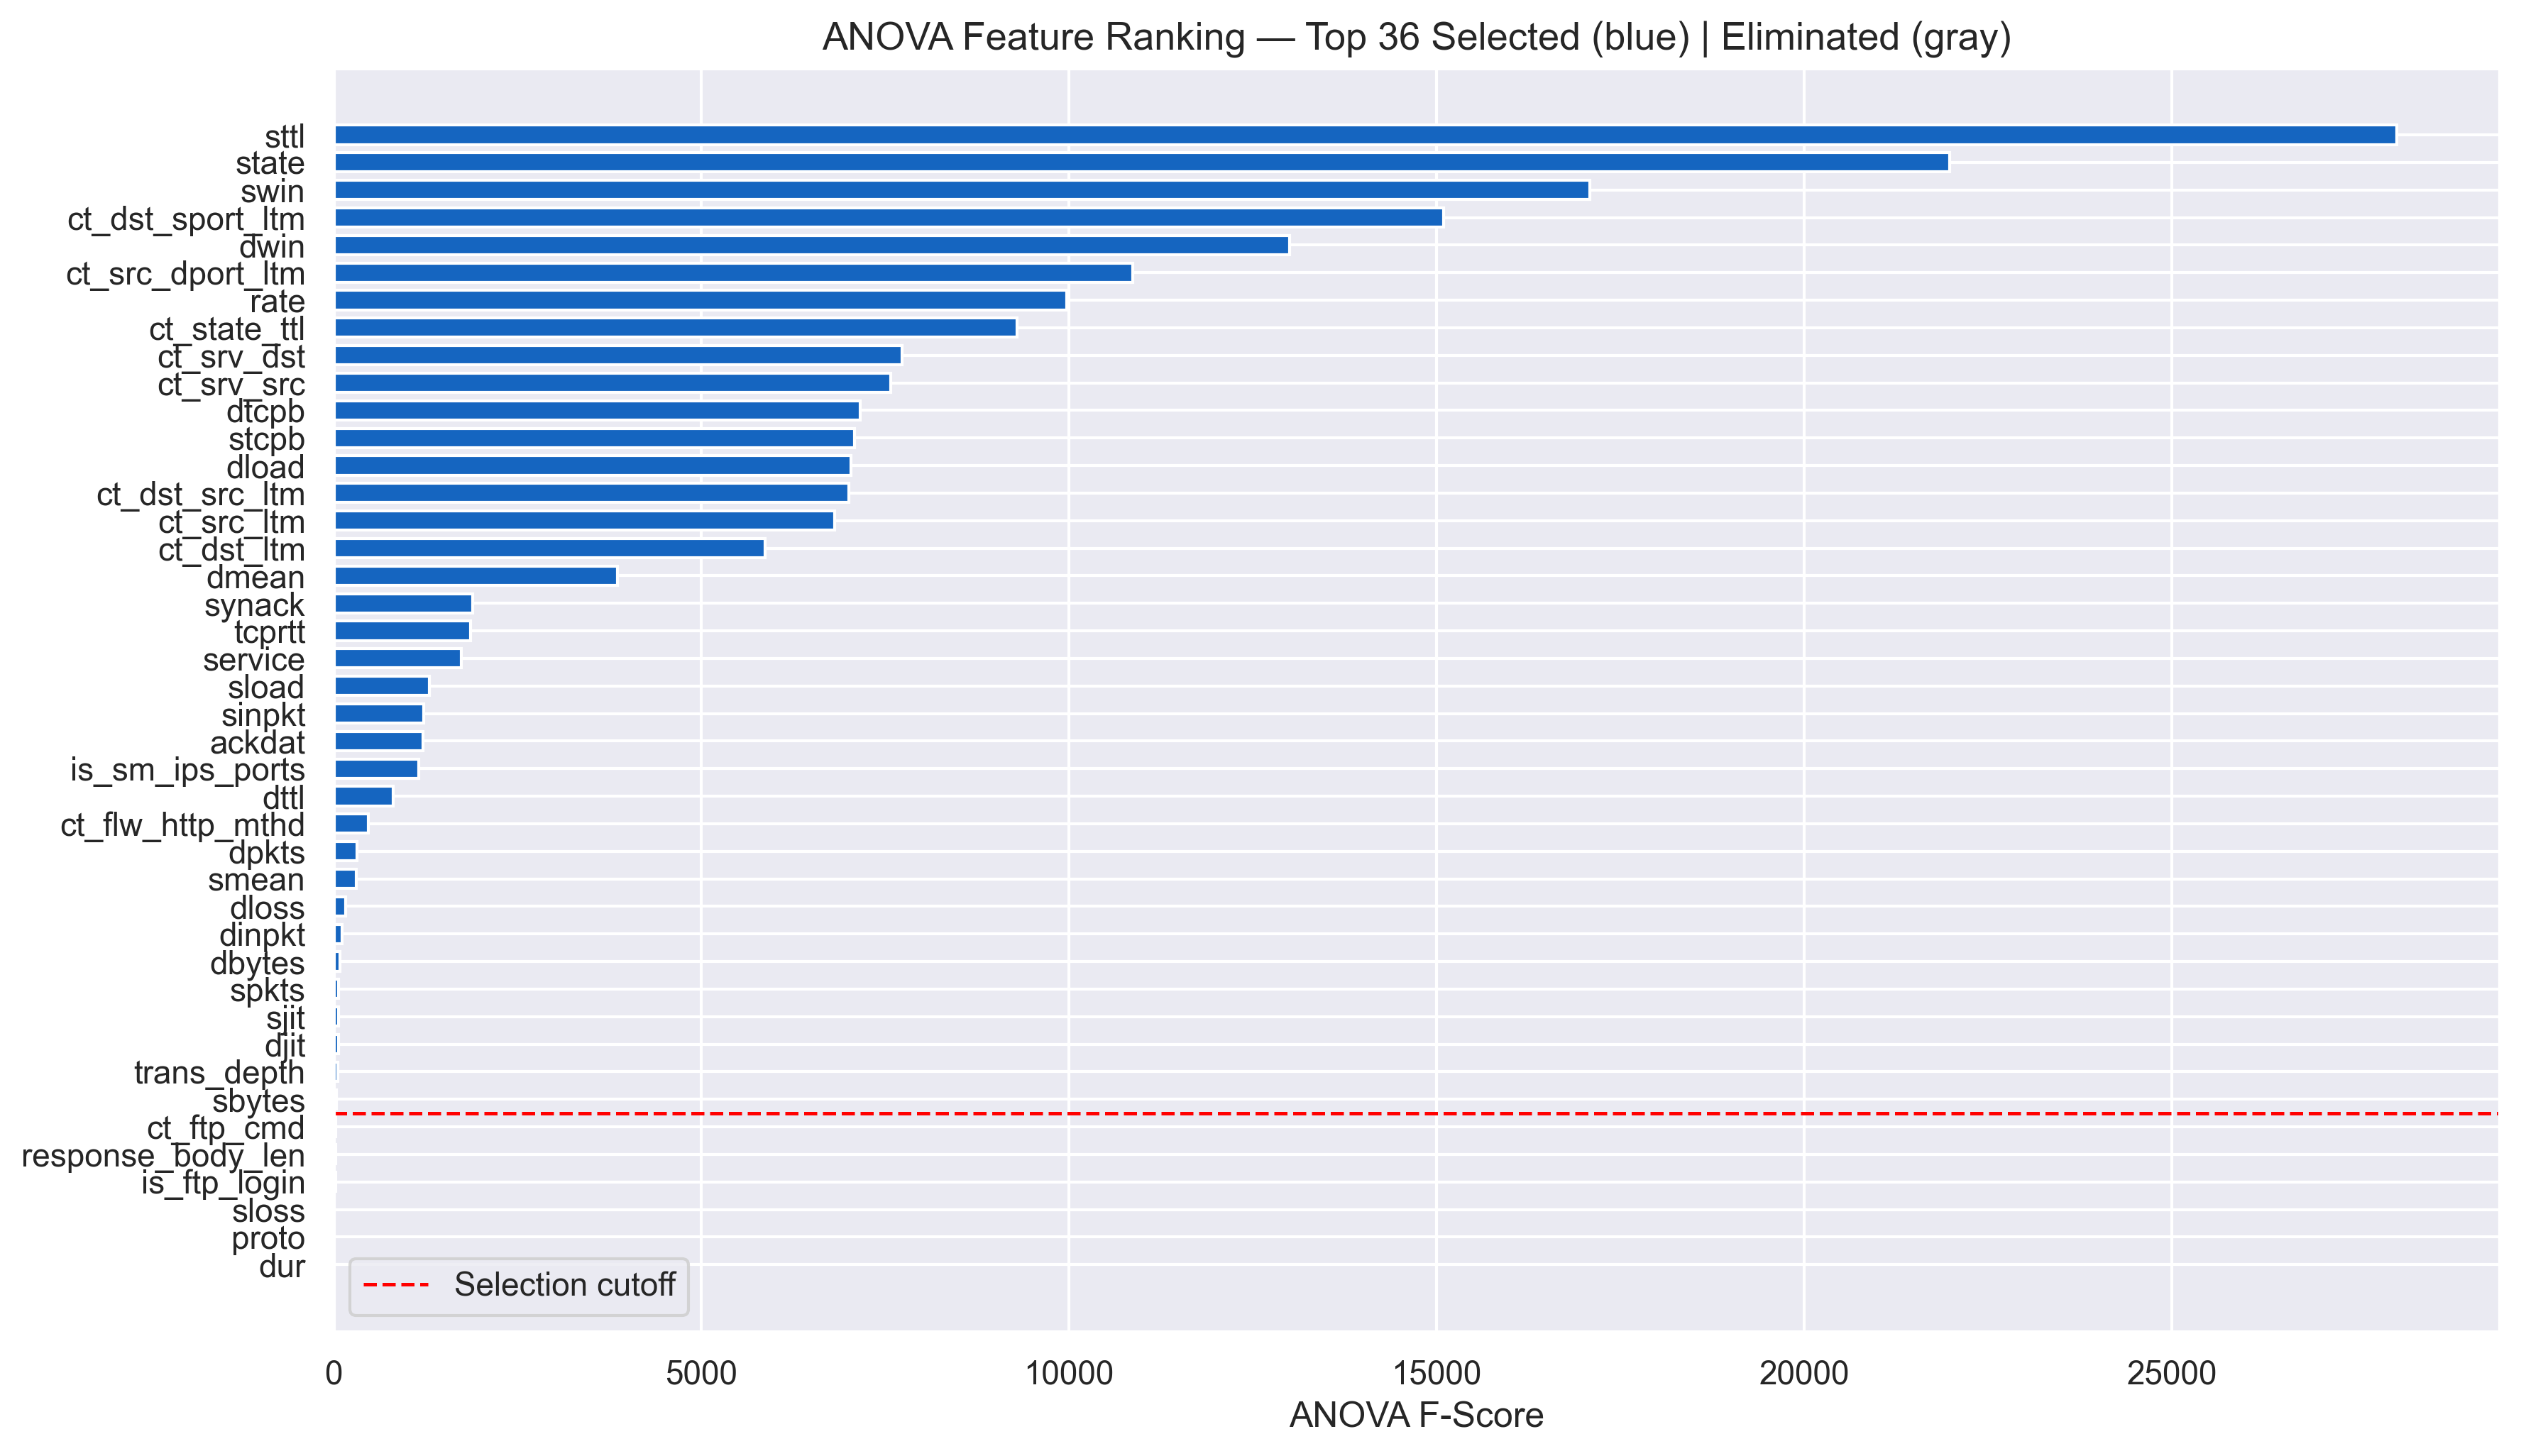

ANOVA plot saved ✓


In [10]:
# Plot ANOVA F-scores
fig, ax = plt.subplots(figsize=(12, 7))

colors = [
    '#1565C0' if f in selected_features else '#B0BEC5'
    for f in anova_df['feature']
]

ax.barh(
    anova_df['feature'][::-1],
    anova_df['f_score'][::-1],
    color=colors[::-1],
    edgecolor='white',
    height=0.7
)
ax.set_xlabel('ANOVA F-Score')
ax.set_title(f'ANOVA Feature Ranking — Top {N_FEATURES} Selected (blue) | Eliminated (gray)')

# Divider line between selected and eliminated
ax.axhline(y=len(eliminated) - 0.5, color='red', linestyle='--', linewidth=1.2, label='Selection cutoff')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'anova_feature_ranking.png'), bbox_inches='tight')
plt.show()
print('ANOVA plot saved ✓')

In [11]:
# Apply ANOVA selection
feature_idx   = [X_train_raw.columns.tolist().index(f) for f in selected_features]

X_train_final = X_train_scaled[:, feature_idx].astype(np.float32)
X_test_final  = X_test_scaled[:, feature_idx].astype(np.float32)

print(f'X_train_final : {X_train_final.shape}')   # (82332, 36)
print(f'X_test_final  : {X_test_final.shape}')    # (175341, 36)
print(f'dtype         : {X_train_final.dtype}')   # float32 (efficient for PyTorch)

X_train_final : (82332, 36)
X_test_final  : (175341, 36)
dtype         : float32


## 7. PCA Visualisation (sanity check)

Good preprocessing → Normal and Attack clusters should be separable in 2D PCA.

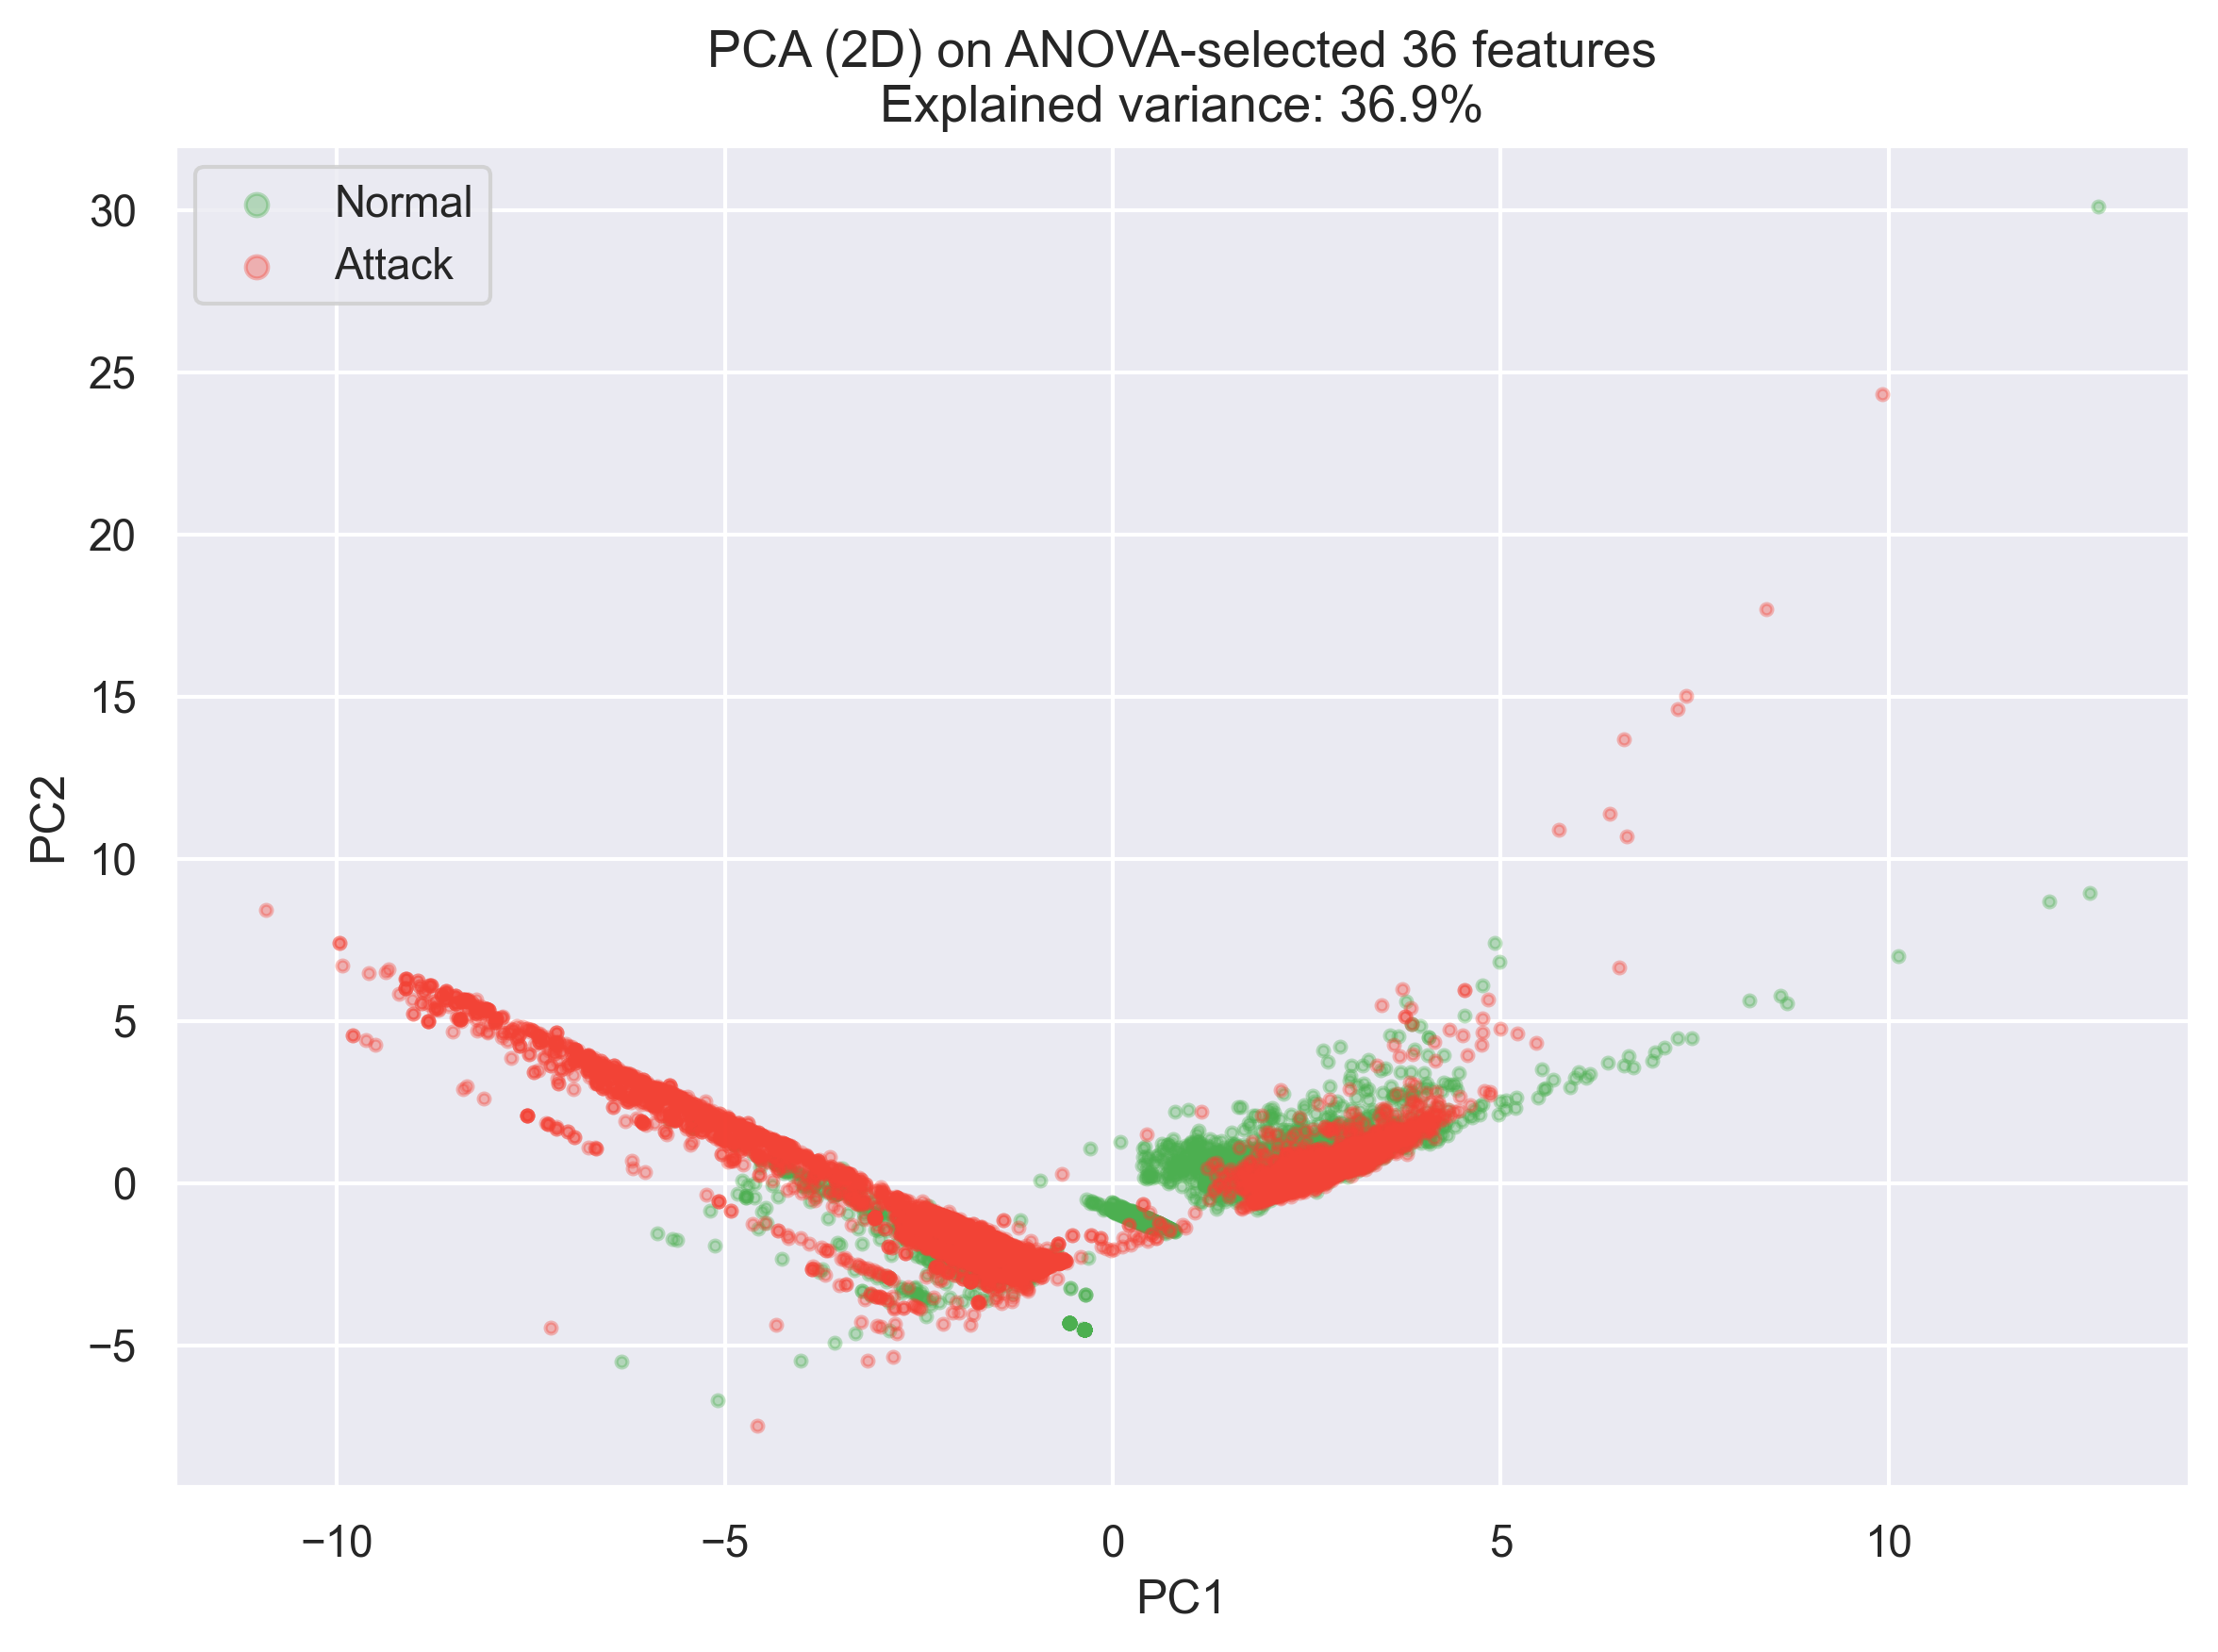

Explained variance by PC1+PC2: 36.9%


In [12]:
# Sample 10k points for speed
sample_idx = np.random.choice(len(X_train_final), size=10_000, replace=False)
X_pca_data = X_train_final[sample_idx]
y_pca_data = y_train[sample_idx]

pca    = PCA(n_components=2, random_state=SEED)
X_pca  = pca.fit_transform(X_pca_data)
var_explained = pca.explained_variance_ratio_.sum() * 100

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, '#4CAF50', 'Normal'), (1, '#F44336', 'Attack')]:
    mask = y_pca_data == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, alpha=0.35, s=8, label=name)

ax.set_title(f'PCA (2D) on ANOVA-selected 36 features\nExplained variance: {var_explained:.1f}%')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'pca_visualization.png'), bbox_inches='tight')
plt.show()
print(f'Explained variance by PC1+PC2: {var_explained:.1f}%')

## 8. Save All Artifacts

In [13]:
# --- numpy arrays ---
np.save(os.path.join(ARTIFACTS_DIR, 'X_train.npy'), X_train_final)
np.save(os.path.join(ARTIFACTS_DIR, 'X_test.npy'),  X_test_final)
np.save(os.path.join(ARTIFACTS_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(ARTIFACTS_DIR, 'y_test.npy'),  y_test)

# --- scaler ---
with open(os.path.join(ARTIFACTS_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# --- label encoders ---
with open(os.path.join(ARTIFACTS_DIR, 'label_encoders.pkl'), 'wb') as f:
    pickle.dump(encoders, f)

# --- selected feature names ---
with open(os.path.join(ARTIFACTS_DIR, 'selected_features.json'), 'w') as f:
    json.dump(selected_features, f, indent=2)

# --- ANOVA ranking table ---
anova_df.to_csv(os.path.join(ARTIFACTS_DIR, 'anova_ranking.csv'), index=False)

print('=== All artifacts saved ===')
for fname in sorted(os.listdir(ARTIFACTS_DIR)):
    fpath = os.path.join(ARTIFACTS_DIR, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f'  {fname:<35} {size:>8.1f} KB')

=== All artifacts saved ===
  X_test.npy                           24657.5 KB
  X_train.npy                          11578.1 KB
  anova_feature_ranking.png              283.4 KB
  anova_ranking.csv                        1.7 KB
  class_distribution.png                 123.3 KB
  label_encoders.pkl                       1.5 KB
  pca_visualization.png                  298.8 KB
  scaler.pkl                               2.0 KB
  selected_features.json                   0.5 KB
  y_test.npy                            1370.0 KB
  y_train.npy                            643.3 KB


## 9. Summary

In [14]:
print('=' * 55)
print('  PREPROCESSING SUMMARY')
print('=' * 55)
print(f'  Dataset          : UNSW-NB15')
print(f'  Task             : Binary classification (Normal vs Attack)')
print(f'  Train samples    : {len(X_train_final):,}')
print(f'  Test  samples    : {len(X_test_final):,}')
print(f'  Original features: {X_train_raw.shape[1]}')
print(f'  Selected features: {N_FEATURES}  (ANOVA F-test, paper-aligned)')
print(f'  Train attack rate: {y_train.mean()*100:.1f}%')
print(f'  Test  attack rate: {y_test.mean()*100:.1f}%')
print(f'  Data dtype       : float32')
print('=' * 55)
print()
print('  Top 5 features by ANOVA F-score:')
for i, row in anova_df.head(5).iterrows():
    print(f'    {i+1}. {row["feature"]:<20}  F = {row["f_score"]:,.0f}')
print()
print('  Next notebook → 02_model_training.ipynb')

  PREPROCESSING SUMMARY
  Dataset          : UNSW-NB15
  Task             : Binary classification (Normal vs Attack)
  Train samples    : 82,332
  Test  samples    : 175,341
  Original features: 42
  Selected features: 36  (ANOVA F-test, paper-aligned)
  Train attack rate: 55.1%
  Test  attack rate: 68.1%
  Data dtype       : float32

  Top 5 features by ANOVA F-score:
    1. sttl                  F = 28,058
    2. state                 F = 21,980
    3. swin                  F = 17,080
    4. ct_dst_sport_ltm      F = 15,099
    5. dwin                  F = 12,998

  Next notebook → 02_model_training.ipynb
